<a href="https://colab.research.google.com/github/ale3665/GANs-Project/blob/main/Seminar_Demo_GANs_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.91MB/s]


Epoch 1/50 | Loss_D: 0.9519 | Loss_G: 1.4066
Epoch 2/50 | Loss_D: 1.3077 | Loss_G: 1.1688
Epoch 3/50 | Loss_D: 0.8353 | Loss_G: 2.1771
Epoch 4/50 | Loss_D: 0.7607 | Loss_G: 2.0065
Epoch 5/50 | Loss_D: 0.7241 | Loss_G: 1.4025
Epoch 6/50 | Loss_D: 0.8953 | Loss_G: 1.4764
Epoch 7/50 | Loss_D: 1.6360 | Loss_G: 0.8081
Epoch 8/50 | Loss_D: 1.0855 | Loss_G: 3.2121
Epoch 9/50 | Loss_D: 0.7000 | Loss_G: 2.0812
Epoch 10/50 | Loss_D: 0.8644 | Loss_G: 1.0882
Epoch 11/50 | Loss_D: 1.0609 | Loss_G: 1.8247
Epoch 12/50 | Loss_D: 1.1779 | Loss_G: 0.7617
Epoch 13/50 | Loss_D: 0.9879 | Loss_G: 1.2325
Epoch 14/50 | Loss_D: 1.1063 | Loss_G: 0.9488
Epoch 15/50 | Loss_D: 1.4349 | Loss_G: 0.4400
Epoch 16/50 | Loss_D: 1.2726 | Loss_G: 1.4647
Epoch 17/50 | Loss_D: 1.3835 | Loss_G: 1.7939
Epoch 18/50 | Loss_D: 1.1572 | Loss_G: 0.8708
Epoch 19/50 | Loss_D: 1.1679 | Loss_G: 0.9627
Epoch 20/50 | Loss_D: 1.1860 | Loss_G: 0.9242
Epoch 21/50 | Loss_D: 1.2058 | Loss_G: 1.1090
Epoch 22/50 | Loss_D: 1.2097 | Loss_G: 0.79

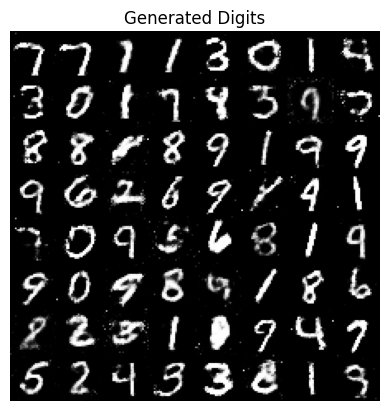

In [ ]:
# GAN on MNIST (Concise, Technical Version)
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Hyperparameters
latent_dim = 100
batch_size = 128
epochs = 50
lr = 0.0002
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Data loader
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataloader = DataLoader(datasets.MNIST('.', download=True, transform=transform), batch_size=batch_size, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 28*28), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# Initialize models
G = Generator().to(device)
D = Discriminator().to(device)
loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# Training loop
for epoch in range(epochs):
    for real, _ in dataloader:
        real = real.to(device)
        z = torch.randn(real.size(0), latent_dim).to(device)
        fake = G(z)

        # Train Discriminator
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_D = loss_fn(D_real, torch.ones_like(D_real)) + loss_fn(D_fake, torch.zeros_like(D_fake))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # Train Generator
        D_fake = D(fake)
        loss_G = loss_fn(D_fake, torch.ones_like(D_fake))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss_D: {loss_D.item():.4f} | Loss_G: {loss_G.item():.4f}")

# Generate and visualize digits
G.eval()
z = torch.randn(64, latent_dim).to(device)
samples = G(z).cpu().detach()
grid = torch.cat([torch.cat([samples[i*8 + j] for j in range(8)], dim=2) for i in range(8)], dim=1)
plt.imshow(grid.squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated Digits')
plt.show()